In [13]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ⟨p* . u⟩ - ⟨p⟩* . ⟨u⟩
# u, p of shape (...T, k...)
def cross_spectrum(p_hat, u_hat, avg_axis=(0,)):
    return np.mean(p_hat.conj() * u_hat, axis=avg_axis) - (np.mean(p_hat, axis=avg_axis).conj() * np.mean(u_hat, axis=avg_axis))
    
# coherence gamma2
# |Spu|2 / [ Spp Suu ]
def compute_coherence(p_hat, u_hat):
    Suu = cross_spectrum(u_hat, u_hat)
    Spu = cross_spectrum(p_hat, u_hat)
    Spp = cross_spectrum(p_hat, p_hat)

    return np.abs(Spu) ** 2 / (Suu * Spp)


# d of shape T, comp (u, v, w, pressure), x, y, z
def coherence_analysis(d, nx, dx, nz, dz, y):
    means = d.mean(axis=(0, 2, 4), keepdims=True)
    flucts = d - means
    flucts_hat = np.fft.fft2(flucts, axes=(2, 4))
    
    flucts_mean_power = (np.abs(flucts_hat[:, 0, :, 1, :]) ** 2).mean((0))
    shifted = np.fft.fftshift(flucts_mean_power)
    plt.imshow(np.log10(shifted + 1e-20), origin='lower', cmap='viridis')
    plt.colorbar(label='log10(power)')
    plt.xlabel('kz index')
    plt.ylabel('kx index')
    plt.show()

    kx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2*np.pi
    kz = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2*np.pi
    KX, KZ = np.meshgrid(kx, kz, indexing='ij')
    K = np.sqrt(KX**2 + KZ**2)

    # bin into radial shells
    k_bins = np.linspace(0, K.max(), 20)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    radial_power = np.zeros(len(k_bins)-1)
    for i in range(len(k_bins)-1):
        mask = (K >= k_bins[i]) & (K < k_bins[i+1])
        radial_power[i] = shifted[mask].sum() if mask.any() else 0
    
    plt.plot(k_bins[:-1], radial_power)

    # Kolmogorov -5/3 reference, anchored to match data at one point
    valid = radial_power > 0
    k_ref, e_ref = k_centers[valid][len(k_centers[valid])//2], radial_power[valid][len(k_centers[valid])//2]
    k_line = k_centers[valid]
    e_line = e_ref * (k_line / k_ref) ** (-5/3)
    plt.plot(k_line, e_line, '--', label=r'$k^{-5/3}$')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('|k|')
    plt.ylabel('mean power')
    plt.legend()
    plt.grid(True)
    plt.show()

    pressure_hat = flucts_hat[:, 3, :, :, :]
    coherence = compute_coherence(pressure_hat[:, :, 0, :][:, None, :, None, :], flucts_hat[:, :, :, :, :])
    
    gamma2 = coherence.real
    
    def plot_coherence(comp_names):
        fig, ax = plt.subplots()
        for i, name in enumerate(comp_names):
            coh_y = gamma2[i].mean(axis=(0, 2))  # mean over kx, kz -> shape (y,)
            ax.plot(y, coh_y, label=name)
        
        ax.set_xlabel('y')
        ax.set_ylabel('mean coherence')
        ax.legend()
        plt.grid(True)
        plt.show()
    plot_coherence(['u', 'v', 'w', 'p'])
    plot_coherence(['u', 'v', 'w'])

    def plot_coherence_map_ax(gamma2, ax, comp_idx, y_idx, kx_freqs, kz_freqs, comp_name=''):
        data = gamma2[comp_idx, :, y_idx, :]           # shape (kx, kz)
        data_shifted = np.fft.fftshift(data, axes=(0, 1))
        kx_shifted = np.fft.fftshift(kx_freqs)
        kz_shifted = np.fft.fftshift(kz_freqs)
    
        ax.imshow(data_shifted, origin='lower', vmin=0, vmax=1, cmap='viridis',
                   extent=[kz_shifted[0], kz_shifted[-1], kx_shifted[0], kx_shifted[-1]])
        ax.set_xlabel('kz'); plt.ylabel('kx')
        ax.set_title(f'{comp_name}, y_idx={y_idx}, y={y[y_idx]:.2f}')

    def plot_coherences(gamma2, y_idx, kx_freqs, kz_freqs,):
        fig, ax = plt.subplots(1, 3, figsize=(13, 5))
        plot_coherence_map_ax(gamma2, ax[0], 0, y_idx, kx_freqs, kz_freqs, 'u')
        plot_coherence_map_ax(gamma2, ax[1], 1, y_idx, kx_freqs, kz_freqs, 'v')
        plot_coherence_map_ax(gamma2, ax[2], 2, y_idx, kx_freqs, kz_freqs, 'w')
        plt.plot()
    
    interact(lambda y_idx: plot_coherences(gamma2, y_idx, kx, kz), y_idx=(0, y.shape[0] - 1, 1));

    def reduced_coherence(gamma2, ax, comp, y_idx, kx, kz, comp_name):
        k_norm = K
    
        bins = np.linspace(0, k_norm.max() + 1e-10, 20)
        groups = [[] for _ in bins]
        for ix in range(len(kx)):
            for iz in range(len(kz)):
                for i, (b, bp1) in enumerate(zip(bins[:-1], bins[1:])):
                    if b <= k_norm[ix, iz] < bp1:
                        groups[i].append(gamma2[comp, ix, y_idx, iz])
        means = np.array([np.mean(g) if len(g) > 0 else np.nan for g in groups])
        maxima = np.array([np.max(g) if len(g) > 0 else np.nan for g in groups])
        ax.plot(bins, means, label="means")
        ax.plot(bins, maxima, label="maxima")
        ax.set_ylim(0, 1)
        ax.set_title(comp_name)
        ax.legend()
    def plot_reduced_coherences(gamma2, y_idx, kx_freqs, kz_freqs, ):
        fig, ax = plt.subplots(1, 3, figsize=(13, 5))
        reduced_coherence(gamma2, ax[0], 0, y_idx, kx, kz, "u")
        reduced_coherence(gamma2, ax[1], 1, y_idx, kx, kz, "v")
        reduced_coherence(gamma2, ax[2], 2, y_idx, kx, kz, "w")
        plt.plot()
    interact(lambda y_idx: plot_reduced_coherences(gamma2, y_idx, kx, kz), y_idx=(0, y.shape[0] - 1, 1));

In [14]:
import h5py
keys = 'u', 'v', 'w', 'p_total'


def extract(real, keys):
    data = []
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data.append(np.array(f[real][k]))
        return np.stack(data, axis=1)

        
def domain():
    data = {}
    keys = ['x', 'y', 'z']
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data[k] = np.array(f[k])
        return data

        
d = extract('R3', keys)
domain = domain()
dx = domain['x'][1] - domain['x'][0]
dz = domain['z'][1] - domain['z'][0]
nx = domain['x'].shape[0]
nz = domain['z'].shape[0]
y = domain['y']

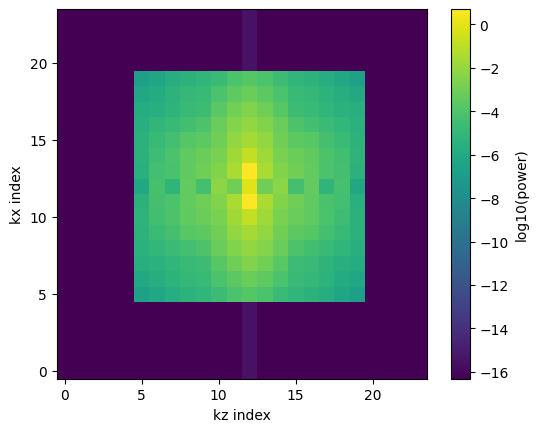

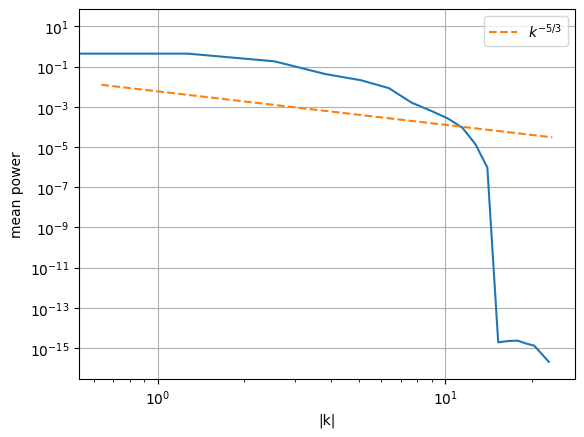

/tmp/ipykernel_643275/3221109944.py:17: RuntimeWarning: overflow encountered in divide
  return np.abs(Spu) ** 2 / (Suu * Spp)
/tmp/ipykernel_643275/3221109944.py:17: RuntimeWarning: invalid value encountered in divide
  return np.abs(Spu) ** 2 / (Suu * Spp)


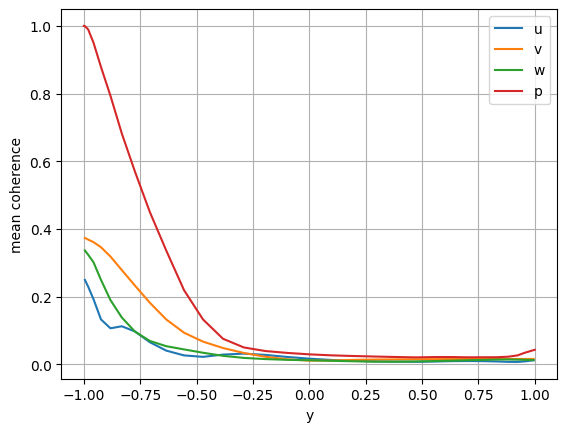

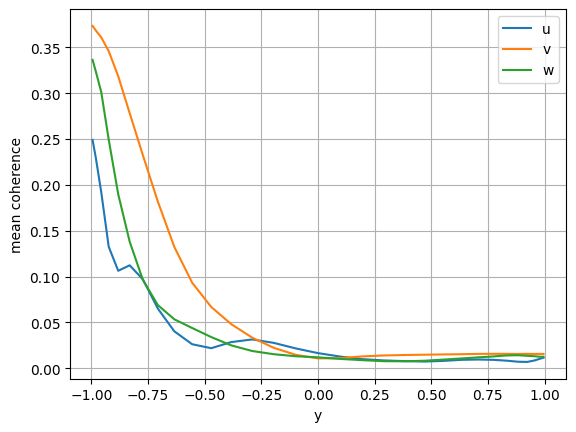

interactive(children=(IntSlider(value=16, description='y_idx', max=32), Output()), _dom_classes=('widget-inter…

interactive(children=(IntSlider(value=16, description='y_idx', max=32), Output()), _dom_classes=('widget-inter…

In [15]:
coherence_analysis(d, nx, dx, nz, dz, y)

In [4]:
import zarr
import s3fs
S3_BUCKET = "simulations"
STORE_PATH = "flow_export/A1"

fs = s3fs.S3FileSystem(profile='default', client_kwargs={
        'endpoint_url': 'http://localhost:9000'
    })

s3_map = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/data.zarr", s3=fs)
z = zarr.open(
    store=s3_map,
    mode="r",
)
store = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/channel.zarr", s3=fs)
channel_z = zarr.open(
    store=store,
    mode="r",
)
channel = {'x': channel_z['x'][:], 'y': channel_z['y'][:], 'z': channel_z['z'][:]}

data = z[60:1510:10]
nx = 128
dx = 12.57 / nx
nz = 128
dz = 4.19 / nz
y = channel["y"]

In [5]:
d = np.stack([data[:, 0], data[:, 1], data[:, 2], data[:, 4]], axis=1)

In [6]:
d.shape

(145, 4, 128, 129, 128)

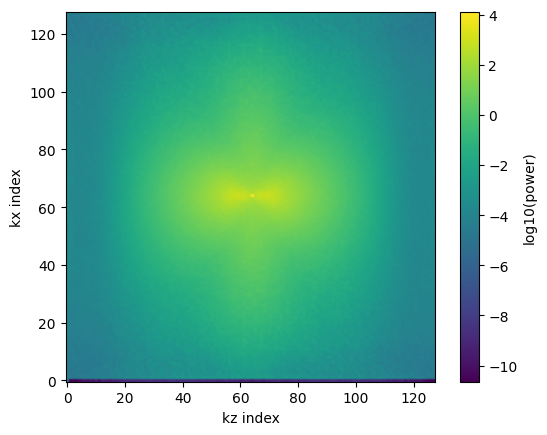

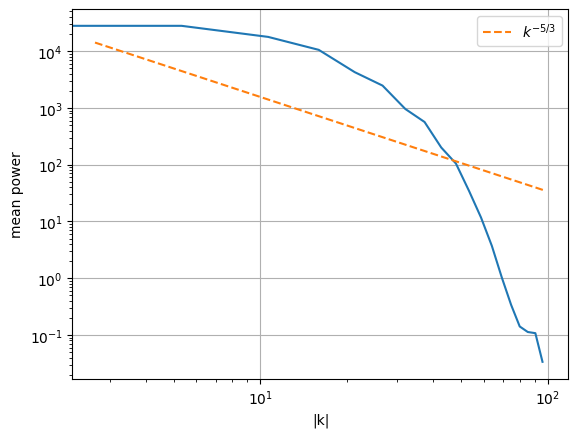

/tmp/ipykernel_643275/1959830007.py:17: RuntimeWarning: invalid value encountered in divide
  return np.abs(Spu) ** 2 / (Suu * Spp)


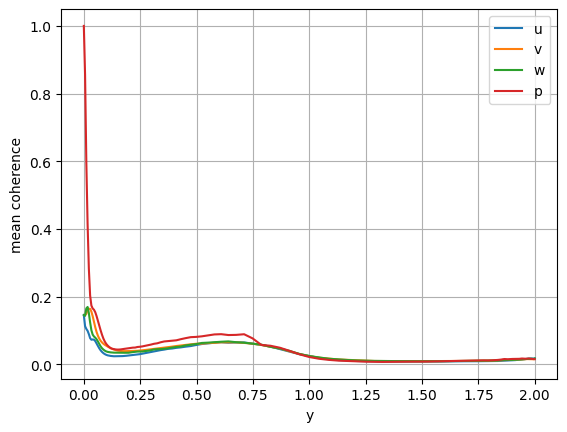

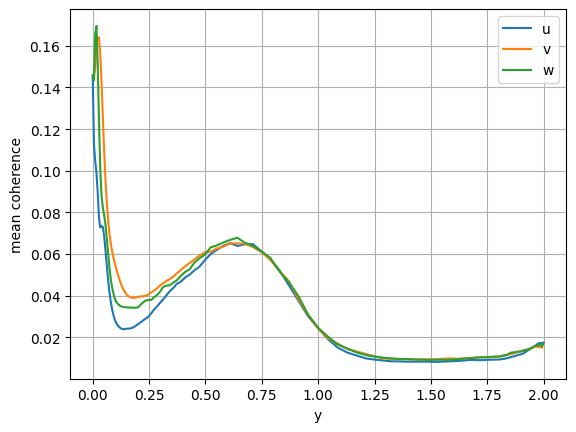

interactive(children=(IntSlider(value=64, description='y_idx', max=128), Output()), _dom_classes=('widget-inte…

interactive(children=(IntSlider(value=64, description='y_idx', max=128), Output()), _dom_classes=('widget-inte…

In [7]:
coherence_analysis(d, nx, dx, nz, dz, y)